## Step 3: Postprocessing: analyze fit results

Import some packages, create some folders. <br> Start this script in the target's main directory (workingdir+'/'+sourcetag) from Step 1.

In [1]:
import pickle
import matplotlib.pyplot as pl
import numpy as np
import corner
import os
import matplotlib

sourcetag = 'hd377'

#Start from target's main directory from Step 1
os.chdir('/Users/jonty/mydata/aca_disks/hd377')

#Read in directories as defined in step 1
miaopath, casapath, carta, sourcetag, workingdir, vis, nvis = pickle.load(open('./dirvises.npy','rb'))
os.chdir('./uvfit')

for i in ['plots', 'uvfit/evaluation']:
    if not os.path.exists(workingdir+'/'+sourcetag+'/'+i):
        os.mkdir(workingdir+'/'+sourcetag+'/'+i)
!cp -rf {miaopath}/utils/maketraceandcornerplot.py {workingdir}/{sourcetag}/uvfit/. 
!cp -rf {miaopath}/utils/uvresidualtoms.py {workingdir}/{sourcetag}/uvfit/. 
!cp -rf {miaopath}/utils/makeuvdeprojplot_simple_multiple.py {workingdir}/{sourcetag}/uvfit/.

Read in results from MCMC visibility fitting through emcee sampler, read from backend as defined in Step 2. 

In [2]:
newbackend=False
backendaddress='backend_'+sourcetag+'_150625_laptop_v1.pkl'
pickle.dump([newbackend, backendaddress], open('backendoptions.npy', 'wb'), protocol=2)

rmin_arcsec, rmax_arcsec, nr = pickle.load(open('./gridparams.npy','rb'))
%run setup_mcmc

#Read in chain
chain=backend.get_chain()

Fast (Fortran90) Mie-scattering module could not be imported. Falling back to the slower Python version.
Radial grid of model goes from 1.0 au to 937.1861390562871 au, with 32 radial steps, and step size of 0.7501491498848454 arcsec
Setting up sampler...


If necessary, remove some walkers that got stuck in unreasonable regions of parameter space (e.g. if they were accidentally started beyond prior boundaries)

In [3]:
#chain=np.delete(chain, np.where(chain[-1,:,8]<=0.25e-3), axis=1)
#chain=np.delete(chain, np.where(chain[600,:,8]<=0.25e-3), axis=1)
#chain=np.delete(chain, np.where(chain[750,:,8]<=0.25e-3), axs=1)

Decide how long the burn-in phase should be, and what the titles of the plots should be. Produce the plots!

Changing units for plotting
Setting labels for ndim parameters
NB: Code is assuming that you chose the end of burn-in phase correctly.


/Users/jonty/mydata/aca_disks/hd377/uvfit/maketraceandcornerplot.py:114: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(cornername+'.pdf')
/Users/jonty/mydata/aca_disks/hd377/uvfit/maketraceandcornerplot.py:126: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  pl.savefig(cornername+'_small.pdf')
/Users/jonty/mydata/aca_disks/hd377/uvfit/maketraceandcornerplot.py:126: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  pl.savefig(cornername+'_small.pdf')
/opt/anaconda3/lib/python3.8/site-packages/IPython/core/events.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  func(*args, **kwargs)


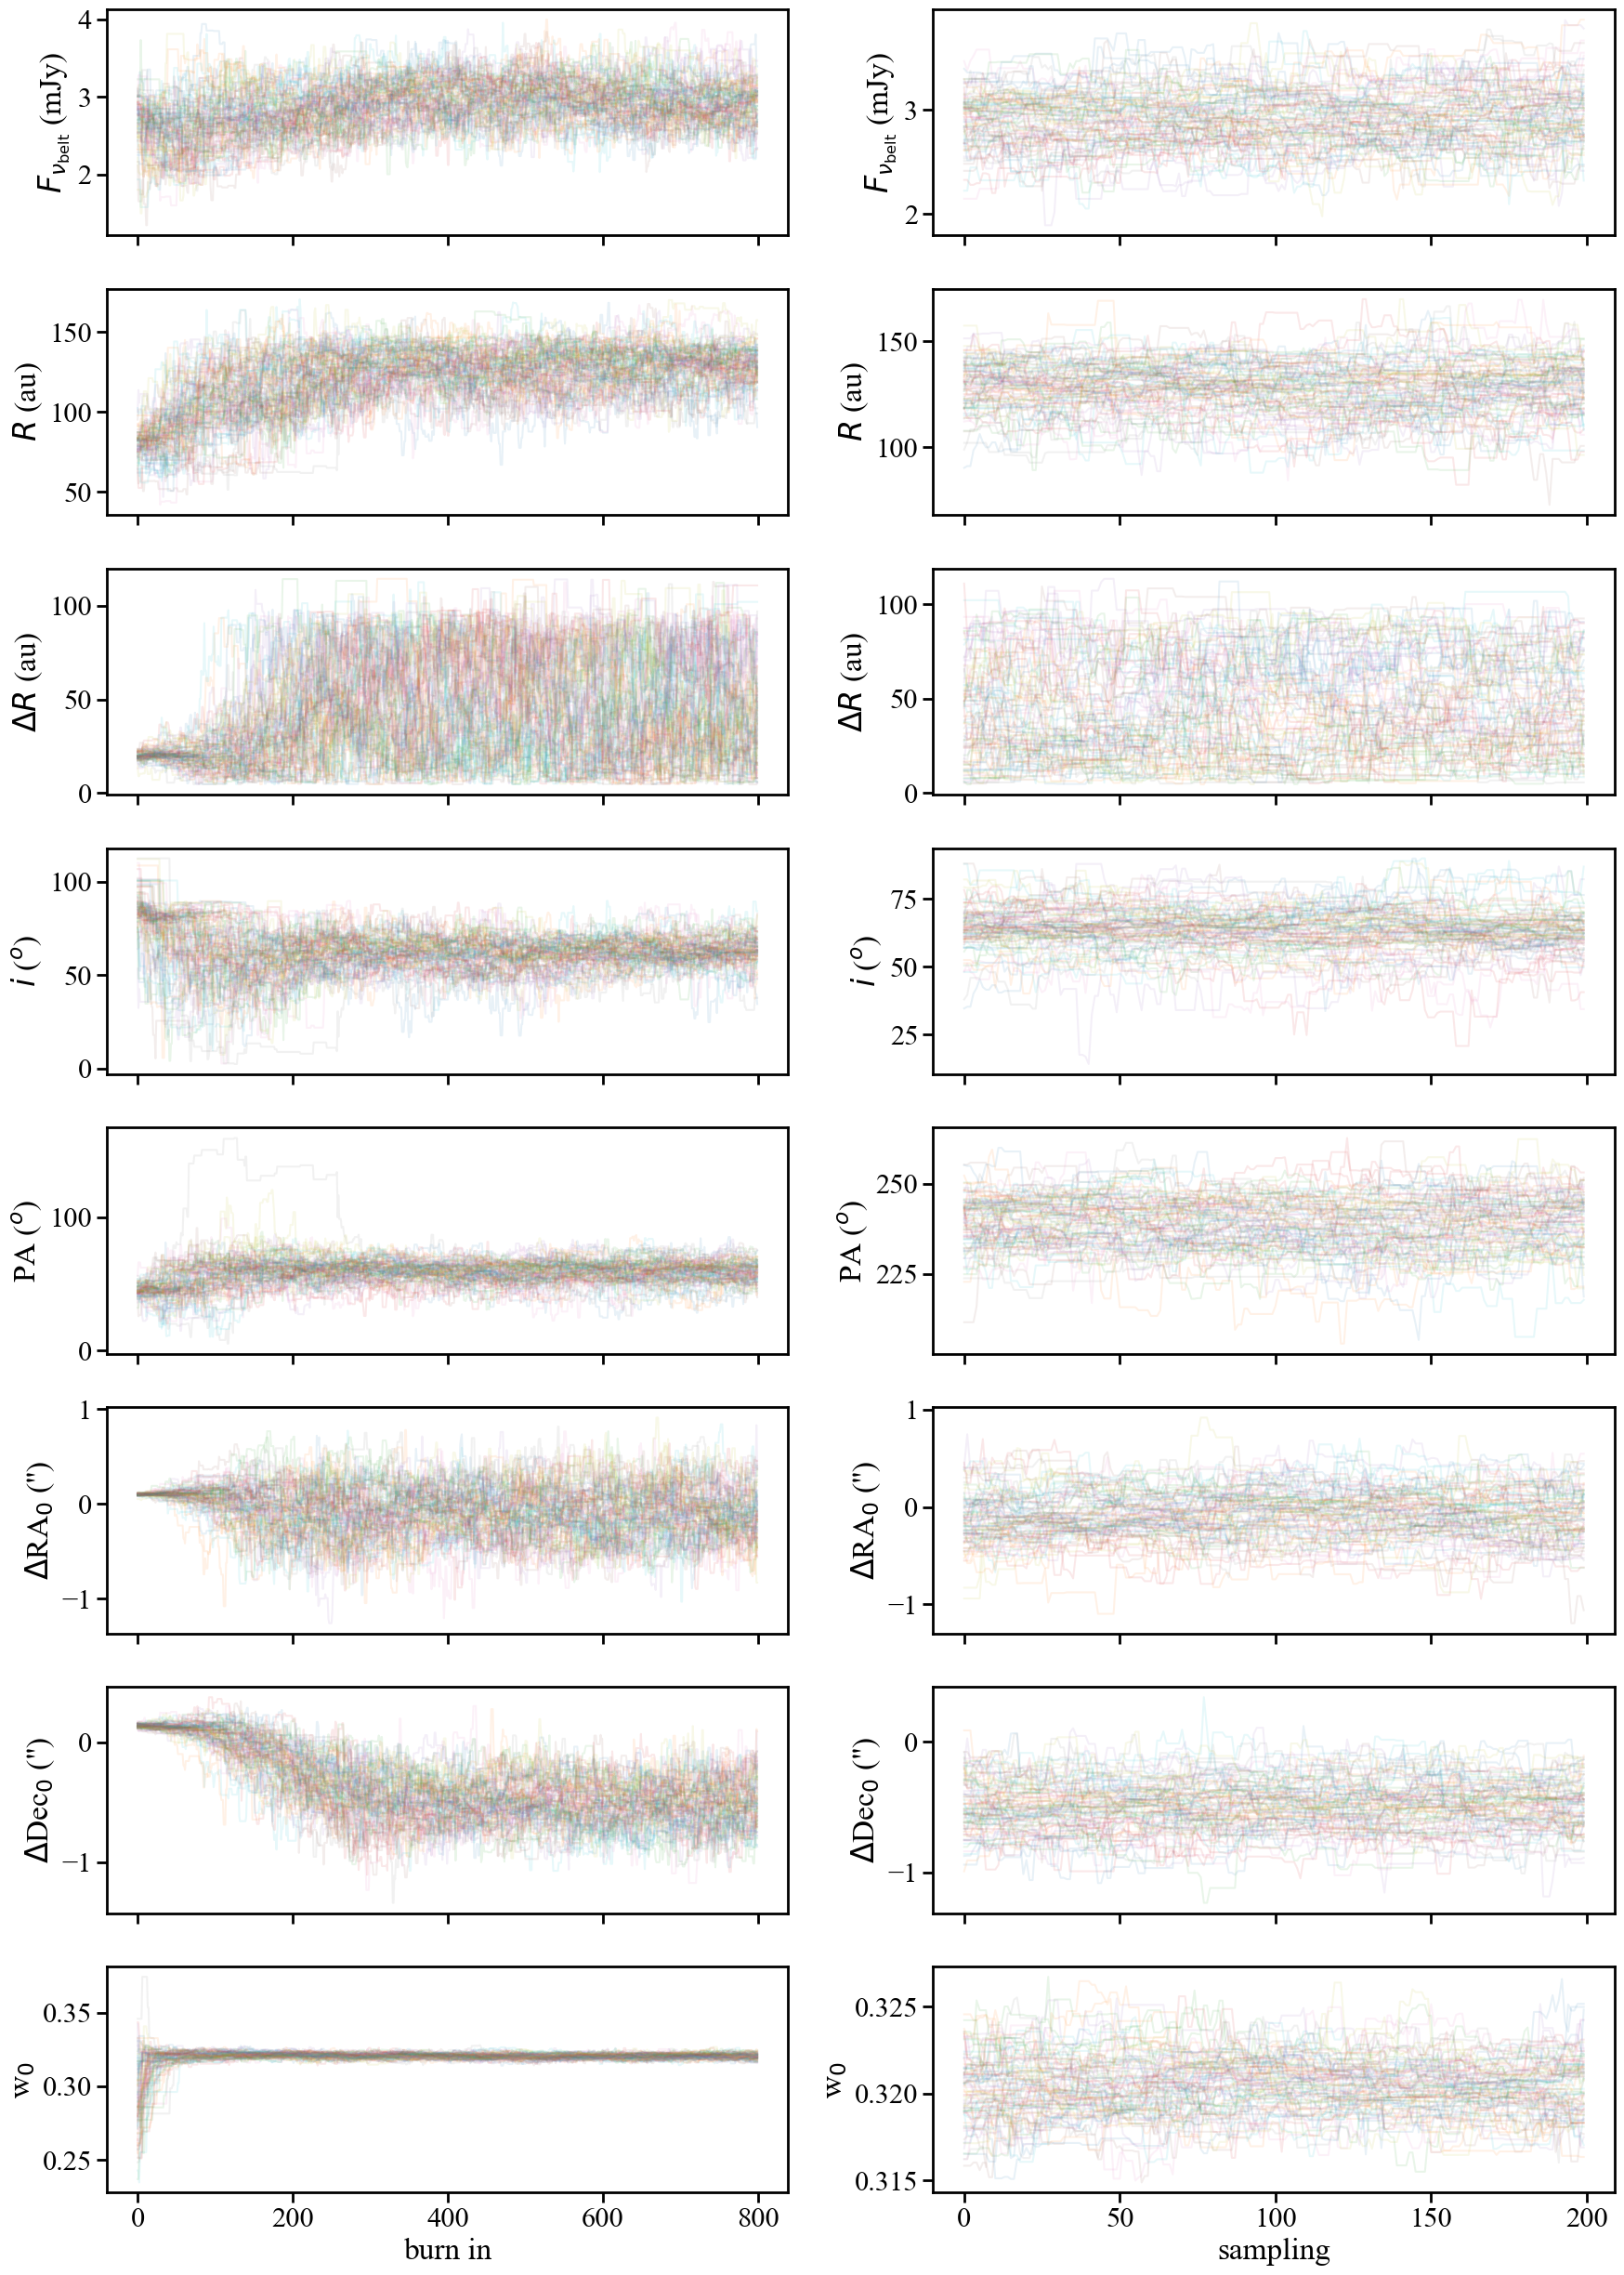

/opt/anaconda3/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


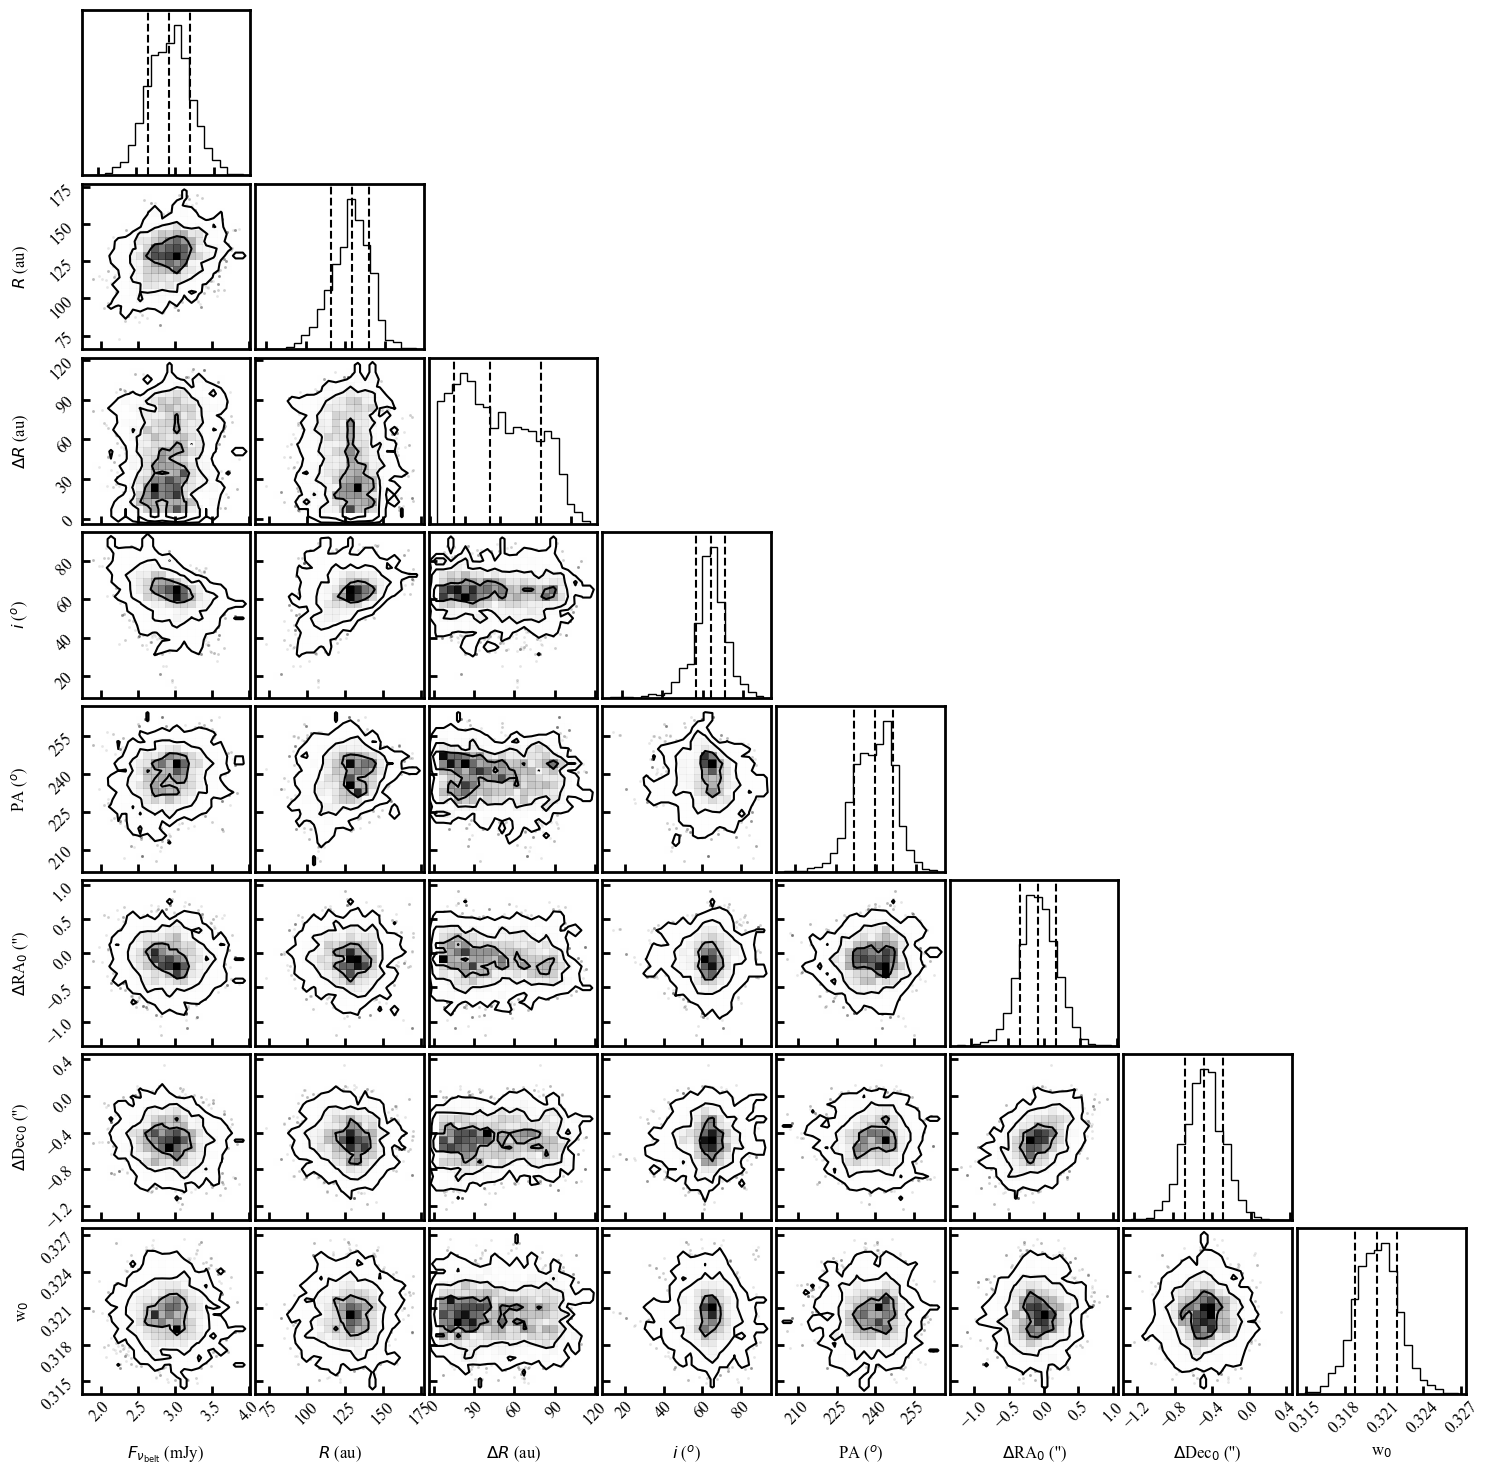

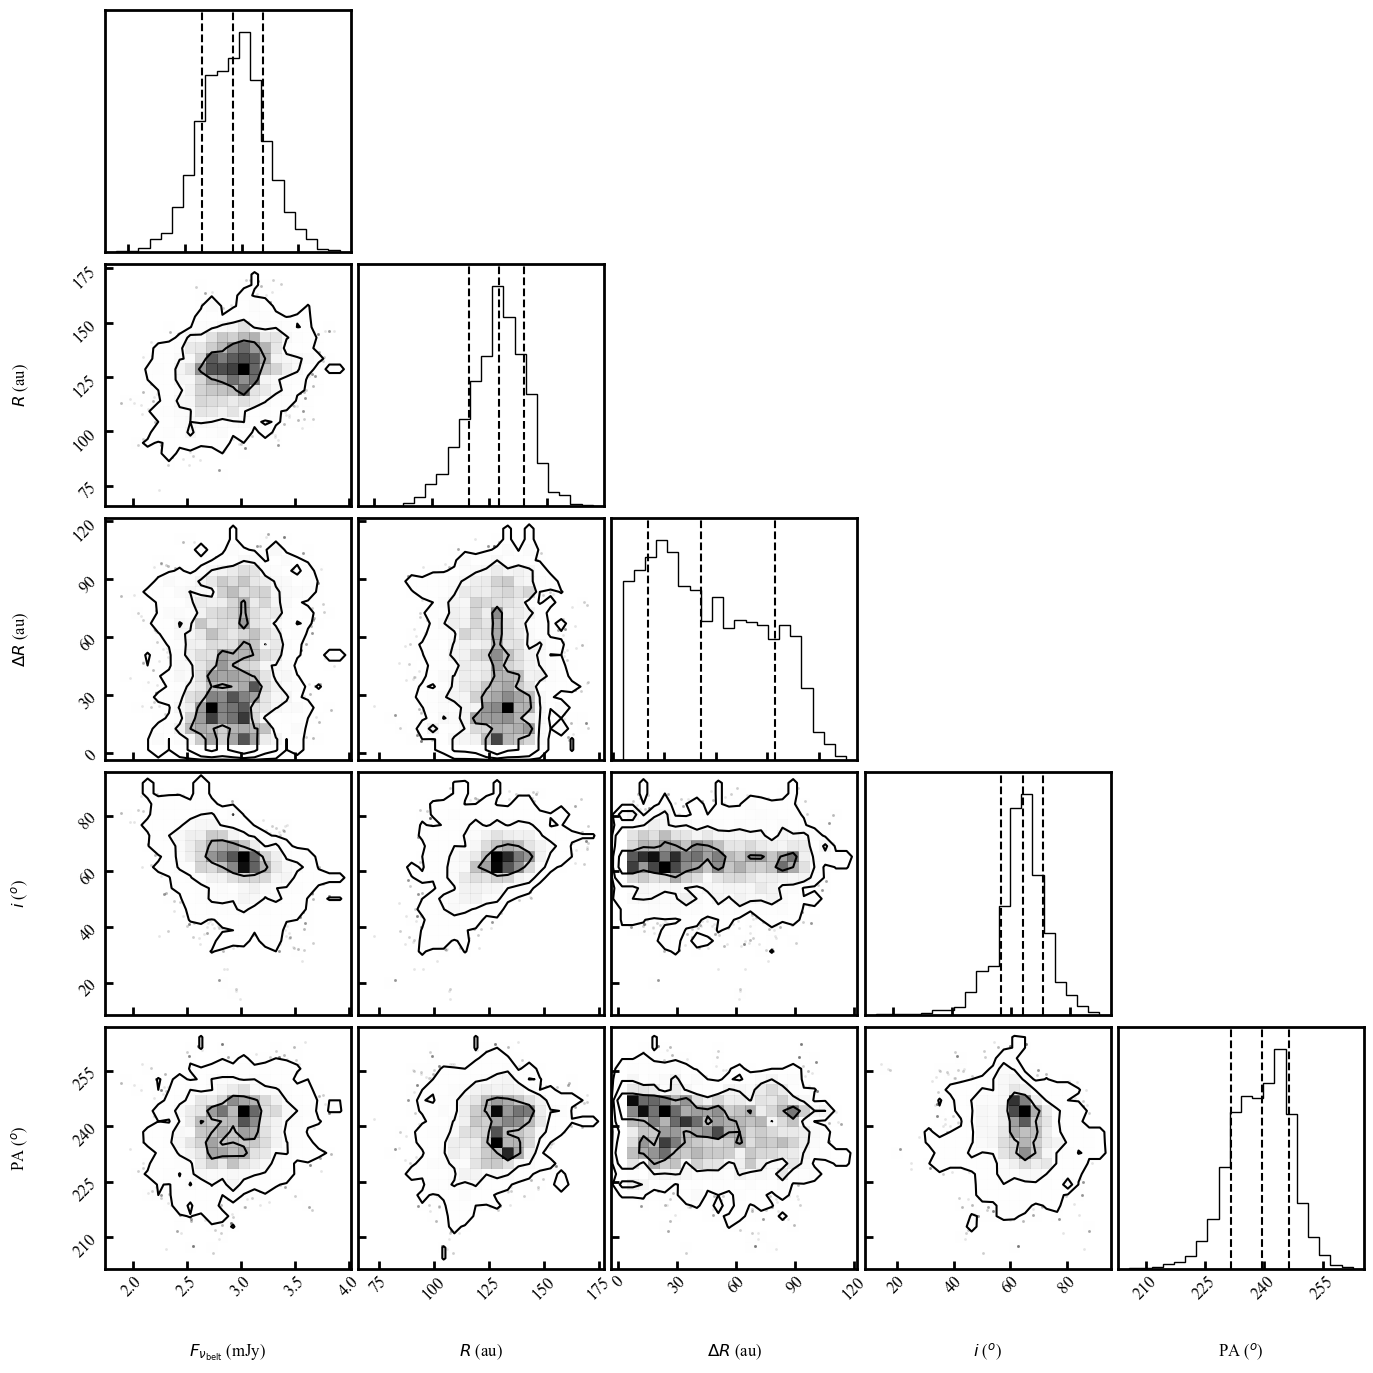

In [4]:
burnin=800

cornername='./evaluation/triangle_'+sourcetag+'_cont'
traceplotname='./evaluation/traceplot_'+sourcetag+'_cont'
pickle.dump([burnin, cornername, traceplotname, chain], open('traceandcornerinputs.npy', 'wb'), protocol=2)

%run maketraceandcornerplot.py
!cp -r ./evaluation/tr* ../plots/.

Now figure out best-fit parameters and upper and lower 1sigma boundaries for every parameter. <br>
These are taken, respectively, as the 50th, 16th, and 84th percentiles of the distributions - which is only good if the
distributions look single- and centrally peaked. If not, it's up to you to modify the values and report parameters as lower or upper limits in your paper!

In [5]:
pbest=list(map(lambda v: (v[1]), zip(*np.percentile(samples, [16,50,84], axis=0))))
pbest1up=list(map(lambda v: (v[2]), zip(*np.percentile(samples, [16,50,84], axis=0))))
pbest1dwn=list(map(lambda v: (v[0]), zip(*np.percentile(samples, [16,50,84], axis=0))))
for i in np.arange(len(pbest)):
    print(labelparams[i],"{:.4f}".format(pbest[i]), "+{:.4f}".format(pbest1up[i]-pbest[i]), "-{:.4f}".format(pbest[i]-pbest1dwn[i]))


$F_{\nu_{\rm belt}}$ (mJy) 2.9246 +0.2647 -0.2716
$R$ (au) 129.1562 +11.0344 -13.2264
$\Delta R$ (au) 42.7269 +35.8463 -25.6110
$i$ ($^{o}$) 63.8679 +6.8185 -7.1852
PA ($^{o}$) 239.5816 +6.8444 -7.9462
$\Delta$RA$_0$ ('') -0.0888 +0.2531 -0.2390
$\Delta$Dec$_0$ ('') -0.4835 +0.1963 -0.1949
w$_0$ 0.3205 +0.0016 -0.0017


(Re-)Produce best-fit model image and visibilities given best fit parameters, quick-check and save image

evaluation
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]] 0.0 0.00015719722723935424 0.7509504319361275
[ 2.92457741e-03  3.31169746e+00  4.65241908e-01  6.38678845e+01
  5.95816464e+01 -8.88021849e-02 -4.83508326e-01  3.20479774e-01]


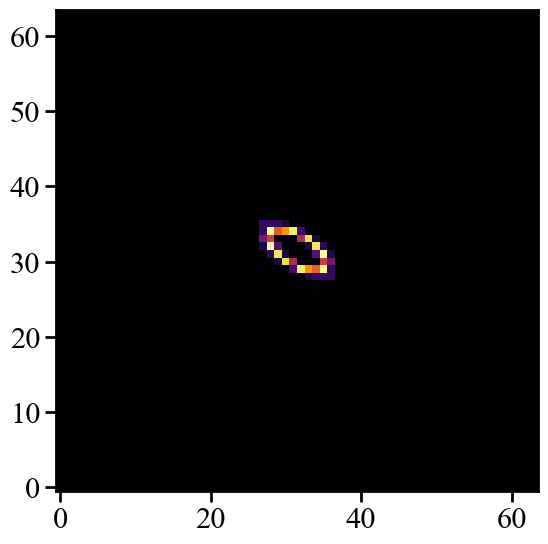

In [6]:
#First turn back to native units from plotting units
pbestformodel=np.asarray(pbest).copy()
pbestformodel[[x for x in range(len(labels)) if labels[x]=='fnu'][0]]/=1e3
if star:
    pbestformodel[[x for x in range(len(labels)) if labels[x]=='fnustar'][0]]/=1e6
pbestformodel[[x for x in range(len(labels)) if labels[x]=='r'][0]]/=dist
pbestformodel[[x for x in range(len(labels)) if labels[x]=='sigr'][0]]/=dist*2.0*np.sqrt(2.0*np.log(2.0))
if pachange:
    pbestformodel[[x for x in range(len(labels)) if labels[x]=='pa'][0]]-=180.0
#Recreate image, obtain model's log-likelihood
locmodelvis= 'evaluation'
print(locmodelvis)
modelim, pxsz, lnL = lnpostfn(pbestformodel, locfiles=locmodelvis)
#Quick check of model image
pl.figure(figsize=(6,6))
pl.imshow(modelim, origin='lower', cmap='inferno')
#Save best-fit model image, and its pixel size, for later plotting
print(modelim,np.min(modelim),np.max(modelim),pxsz)
print(pbestformodel)
np.save('./evaluation/'+sourcetag+'_material_modelim.npy', np.asarray([modelim, pxsz],dtype=object), allow_pickle=True)

Now make deprojected real and imaginary visibility plots with data vs model. <br>
Remember to define your plot parameters appropriately below.

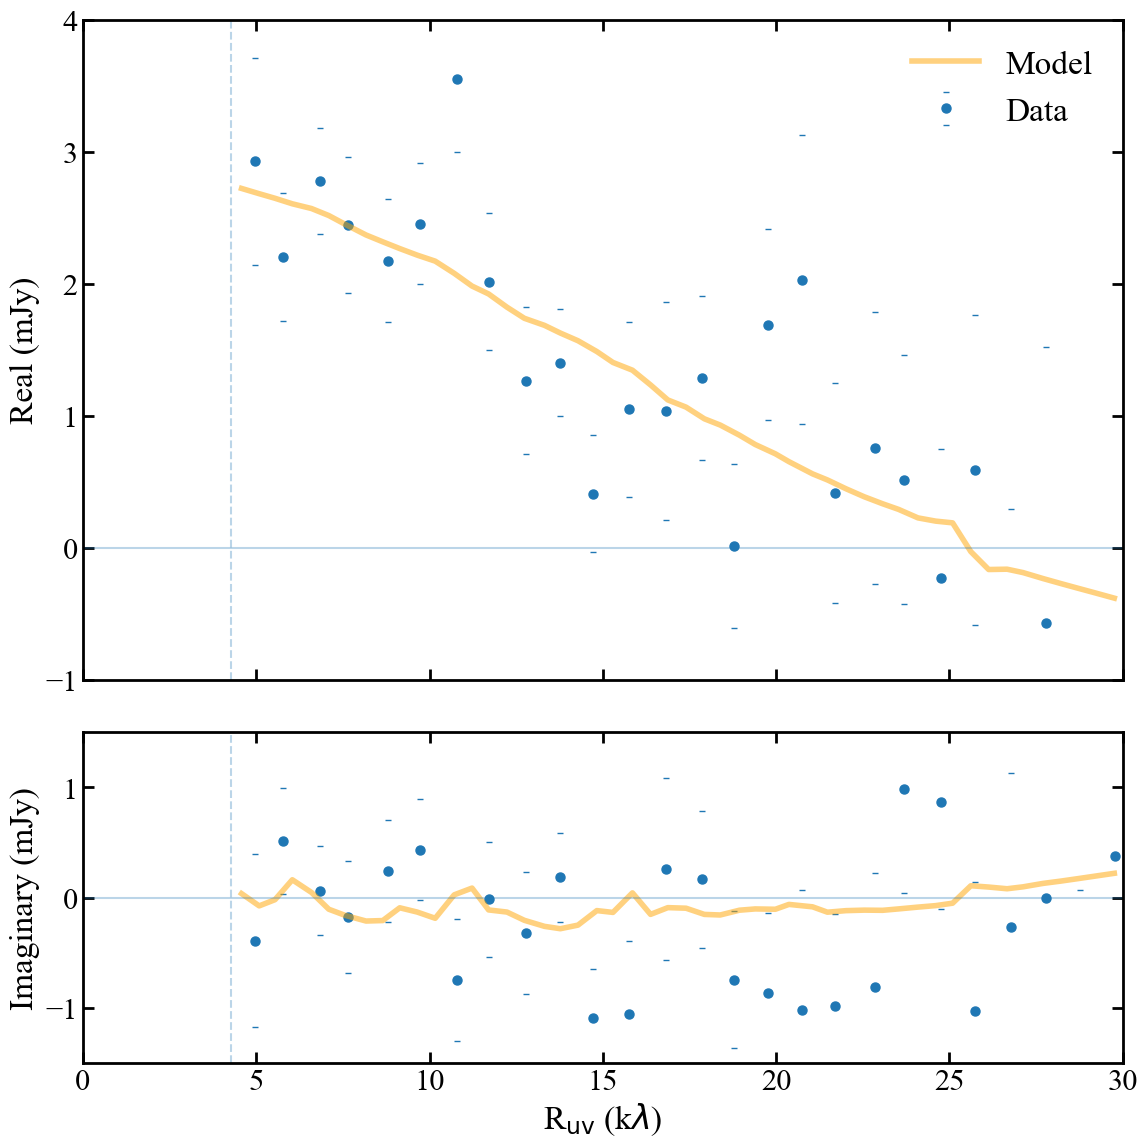

In [7]:
#Import routine
import makeuvdeprojplot_simple_multiple
import importlib
importlib.reload(makeuvdeprojplot_simple_multiple)
#Set weight factor for proper error bars
warr=np.load('./evaluation/warr.npy')

#Provide location of visibilities for data, model, PA, inc and best-fit offset parameters for each dataset (which we will use
#to realign datasets). Normally you should NOT need to change these locations as they are standardised
datavisloc=['../calibratedms/'+vis[i][:-3]+'.npy' for i in np.arange(nvis)]
modelvisloc=[locmodelvis+'/'+sourcetag+'_uvtable_model'+str(i)+'.npy' for i in np.arange(nvis)]
paradoffsetloc=[locmodelvis+'/bestfitshiftPAinc_rad'+str(i)+'.npy' for i in np.arange(nvis)]

#Do you want to phase shift data, model and residual datasets so star+disk are centered at the phase center of 
#each observation? NOTE: if observation is a mosaic, and offsets are defined with respect to the star (rather than
#each pointing center) this should be turned OFF.
phaseshift=True

#Maximum u-v distance to plot
uvmax=30.e3
#Bin size of u-v bins
uvbin_size=1e3
#Lower and upper limit of Real part plot
ylimreal=[-1,4] #Limits on y axis in mJy
#Lower and upper limit of Imaginary part plot
ylimimag=[-1.5,1.5] #Limits on y axis in mJy
#Name of output plot
outfile='./evaluation/'+sourcetag+'_deprojvis.pdf'

#Execute plot.
uvbins, uvbins_mod, bin_re, bin_re_err, bin_re_modfine, bin_im, bin_im_err, bin_im_modfine = makeuvdeprojplot_simple_multiple.makeuvdeprojplot(datavisloc, modelvisloc, paradoffsetloc, uvmax, uvbin_size, warr, ylimreal, ylimimag, outfile, sourcetag, phaseshift)
#Save output for later plotting.
np.save('./evaluation/'+tag+'_material_uvplot.npy', 
        np.asarray([uvbins, uvbins_mod, bin_re, bin_re_err, bin_re_modfine, bin_im, bin_im_err, bin_im_modfine, ylimreal, ylimimag, uvmax],dtype=object), allow_pickle=True)

And finally, use CASA to produce model (noiseless) and residual MS files and dirty images. <br>
Additionally, produce a reweighted and phase shifted dataset - this may improve the original imaging particularly if you
had multiple datasets with wildly different weight rescaling factors, and with large spatial offsets from the phase 
center.

In [8]:
!{casapath}/casa -c uvresidualtoms.py


optional configuration file config.py not found, continuing CASA startup without it

]0;IPython: hd377/uvfitNo event loop hook running.
Using matplotlib backend: <object object at 0x1078a1960>
CASA 6.6.1.17 -- Common Astronomy Software Applications [6.6.1.17]
Traceback (most recent call last):
  File "/Applications/CASA.app/Contents/Frameworks/Python.framework/Versions/3.8/lib/python3.8/site-packages/casashell/private/init_system.py", line 233, in __evprop__
    run_path( args[0], init_globals=exec_globals, run_name='__main__' )
  File "/Applications/CASA.app/Contents/Frameworks/Python.framework/Versions/3.8/lib/python3.8/runpy.py", line 265, in run_path
    return _run_module_code(code, init_globals, run_name,
  File "/Applications/CASA.app/Contents/Frameworks/Python.framework/Versions/3.8/lib/python3.8/runpy.py", line 97, in _run_module_code
    _run_code(code, mod_globals, init_globals,
  File "/Applications/CASA.app/Contents/Frameworks/Python.framework/Versions/3.8/lib/python3.8

As in the imaging tutorial, decide on parameters that you want for CASA imaging through tclean. See CASA tclean documentation for more info.
By default, we will produce images with pixel and image sizes chosen according to the u-v distances covered in the dataset (see later). Multiscale deconvolution will be used.

In [9]:
os.chdir('evaluation')
# Take the same imaging parameters as used for initial images
sourcetag,workingdir,vis,nvis,mosaic,phasecenter,weighting,robust,uvtaper,interactive = pickle.load(open('../../imaging/imagepars.npy','rb'))

# Change anything you want, if you want
# weighting='briggs'
# robust=0.5
interactive=False

visrwdat=[[] for x in vis]
vismodel=[[] for x in vis]
visresidual=[[] for x in vis]
for i in range(nvis):
    visrwdat[i]=sourcetag+'_calibratedvis_cont_'+str(i)+'_rwdat.ms'
    vismodel[i]=sourcetag+'_calibratedvis_cont_'+str(i)+'_model.ms'
    visresidual[i]=sourcetag+'_calibratedvis_cont_'+str(i)+'_res.ms'

#Image reweighted and phase shifted data
pickle.dump([sourcetag,workingdir,visrwdat,nvis,mosaic,phasecenter,weighting,robust,uvtaper,interactive], open('./imagepars.npy', 'wb'), protocol=2)
!{casapath}/casa -c ../../imaging/imagingscript_multiple.py

#Image model
pickle.dump([sourcetag,workingdir,vismodel,nvis,mosaic,phasecenter,weighting,robust,uvtaper,interactive], open('./imagepars.npy', 'wb'), protocol=2)
!{casapath}/casa -c ../../imaging/imagingscript_multiple.py

#Image residuals
pickle.dump([sourcetag,workingdir,visresidual,nvis,mosaic,phasecenter,weighting,robust,uvtaper,interactive], open('./imagepars.npy', 'wb'), protocol=2)
!{casapath}/casa -c ../../imaging/imagingscript_multiple.py


optional configuration file config.py not found, continuing CASA startup without it

]0;IPython: uvfit/evaluationNo event loop hook running.
Using matplotlib backend: <object object at 0x112a5b960>
CASA 6.6.1.17 -- Common Astronomy Software Applications [6.6.1.17]
2025-08-29 04:22:57	WARN	task_tclean::SIImageStore::restore (file /Users/casaci/bamboohome/xml-data/build-dir/CASA-CRBC661-BPOSX12P38/casa6/casatools/src/code/synthesis/ImagerObjects/SIImageStore.cc, line 2284)	Restoring with an empty model image. Only residuals will be processed to form the output restored image.

optional configuration file config.py not found, continuing CASA startup without it

]0;IPython: uvfit/evaluationNo event loop hook running.
Using matplotlib backend: <object object at 0x10523e960>
CASA 6.6.1.17 -- Common Astronomy Software Applications [6.6.1.17]
2025-08-29 04:23:03	WARN	task_tclean::SIImageStore::restore (file /Users/casaci/bamboohome/xml-data/build-dir/CASA-CRBC661-BPOSX12P38/casa6/casatool

Now check the residuals (_ res), the model (_ model) and the reweighted+phase shifted data (_ rwdat)

In [10]:
!{carta}

CARTA will use the default ephemerides and geodetic data.

[2025-08-29 04:23:10.567Z] [CARTA] [info] Writing to the log file: /Users/jonty/.carta/log/carta.log
[2025-08-29 04:23:10.568Z] [CARTA] [info] /Applications/CARTA.app/Contents/Resources/app/carta-backend/bin/carta_backend: Version 5.0.3

[2025-08-29 04:23:10.569Z] [CARTA] [info] Serving CARTA frontend from /Applications/CARTA.app/Contents/Resources/app

[2025-08-29 04:23:10.570Z] [CARTA] [info] Listening on port 5469 with top level folder /, starting folder /Users/jonty/mydata/aca_disks/hd377/uvfit/evaluation. The number of OpenMP worker threads will be handled automatically.
[2025-08-29 04:23:10.570Z] [CARTA] [info] CARTA is accessible at http://localhost:5469/?token=45b93b33-5578-4472-b08b-54e877fefc4f

[2025-08-29 04:23:11.451Z] [CARTA] [info] 0x7f9265a058d0 ::Session (1630850797:1)
[2025-08-29 04:23:11.451Z] [CARTA] [info] Session 1630850797 [127.0.0.1] Connected. Num sessions: 1



If you're happy with the results, time to prepare some plots for the paper in the next tutorial (Step 4)!